In [1]:
#import libraries
import pickle
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score




In [2]:
#load the dataset
df = pd.read_csv('water_potability.csv')
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [3]:
df.shape

(3276, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [6]:
(df.isnull().sum()/df.shape[0])*100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [7]:
df.duplicated().sum()                                                                                            

np.int64(0)

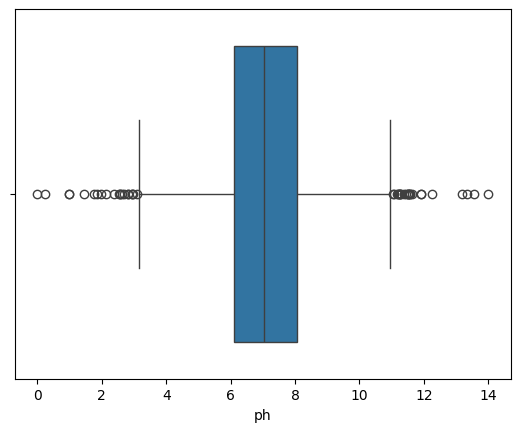

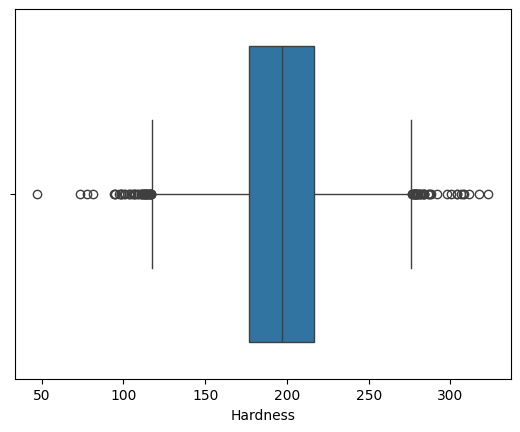

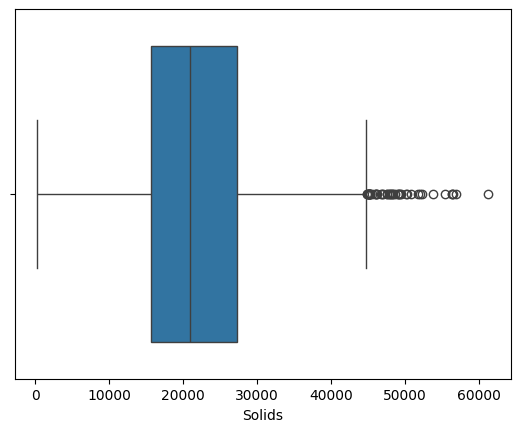

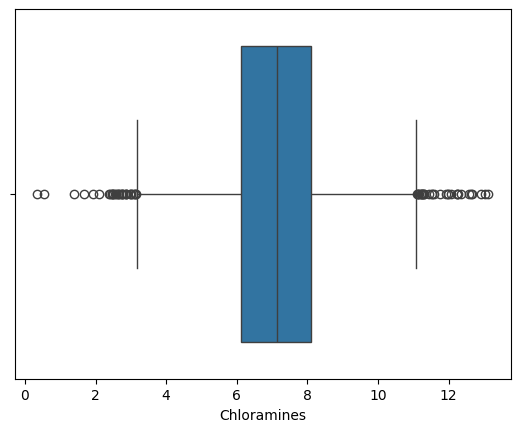

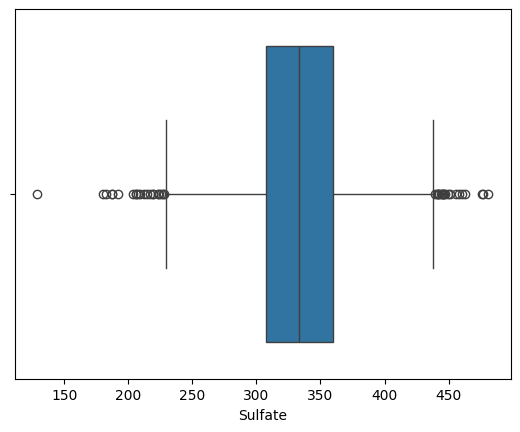

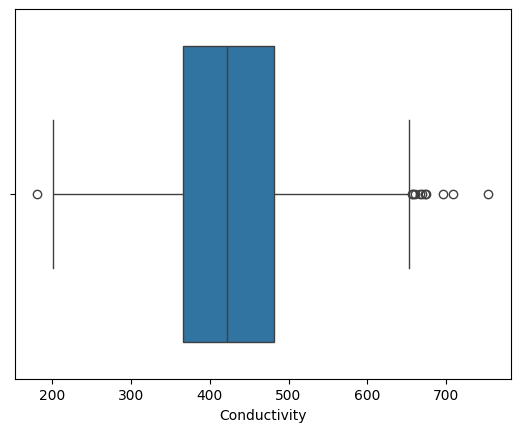

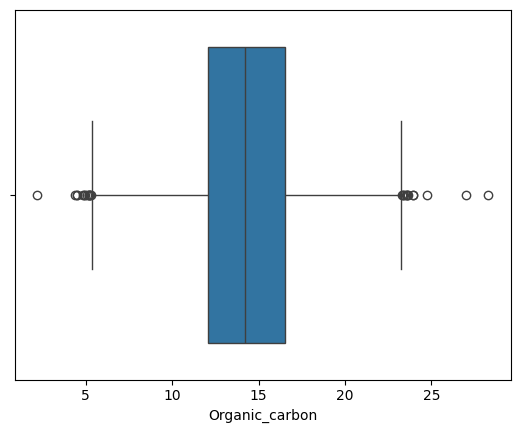

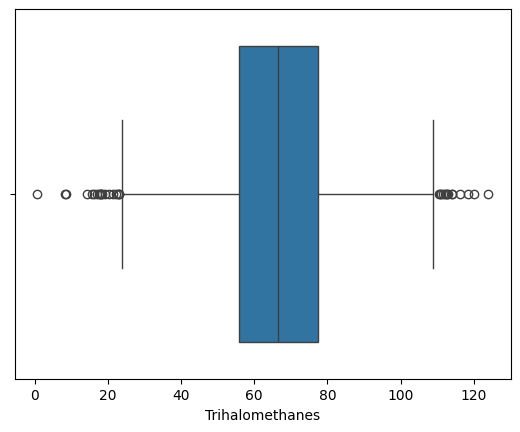

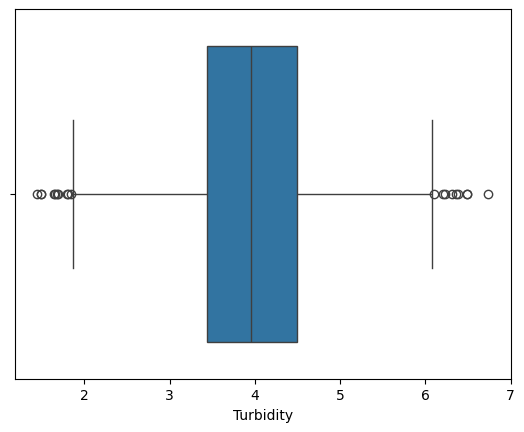

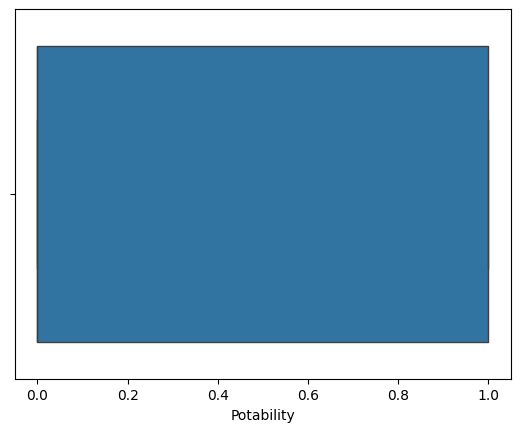

In [8]:
warnings.filterwarnings('ignore')
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()

<Axes: >

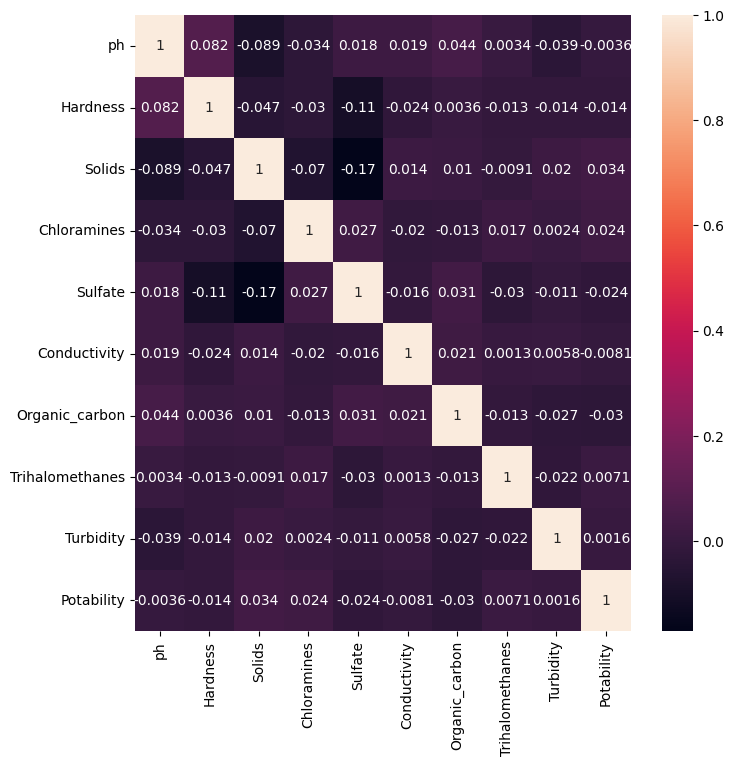

In [9]:
s = df.select_dtypes(include='number').corr()
plt.figure(figsize=(8,8))
sns.heatmap(s,annot=True)

In [10]:
for i in ['ph','Sulfate','Trihalomethanes']:
    df[i].fillna(df[i].median(),inplace=True)

In [11]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [12]:
def outliers(col):
    q1,q3 = np.percentile(col,[25,75])
    iqr = q3-q1
    lower_bound = q1-(1.5*iqr)
    upper_bound = q3+(1.5*iqr)
    return lower_bound,upper_bound


In [13]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [14]:
for i in ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity']:
    lower_bound,upper_bound = outliers(df[i])
    df[i] = np.where(df[i]>upper_bound,upper_bound,df[i])
    df[i] = np.where(df[i]<lower_bound,lower_bound,df[i])

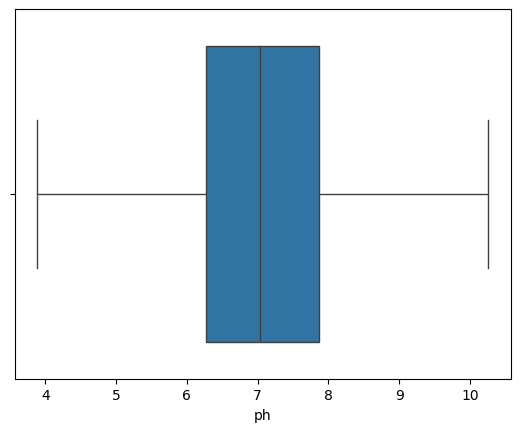

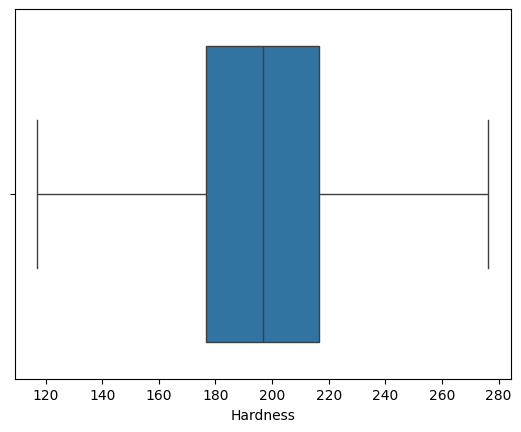

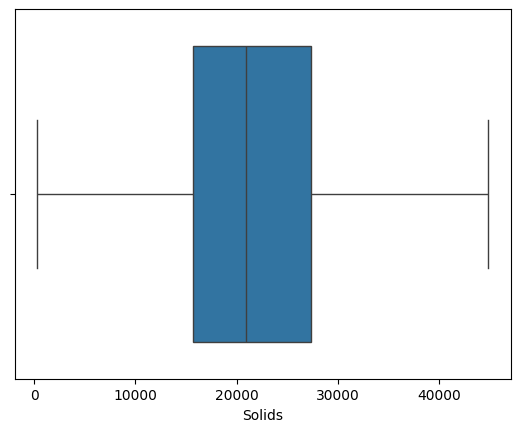

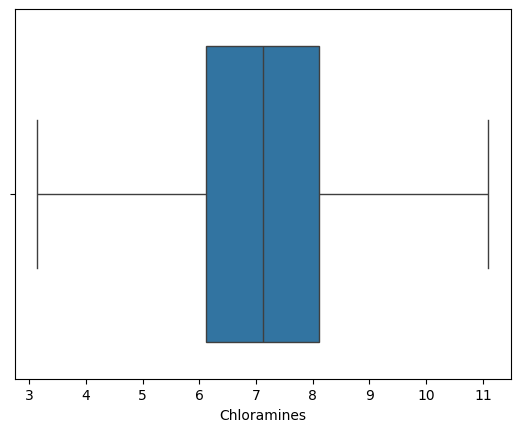

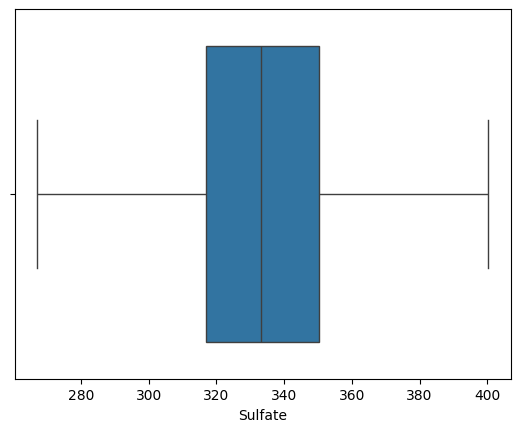

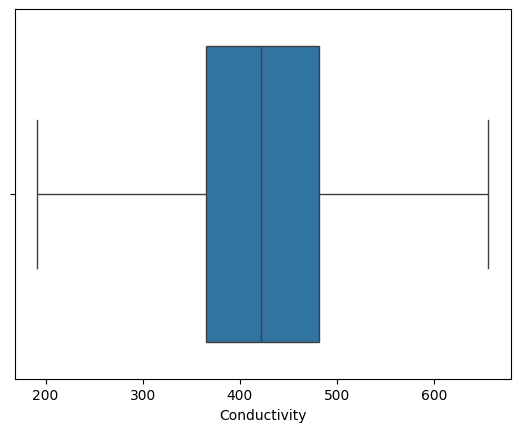

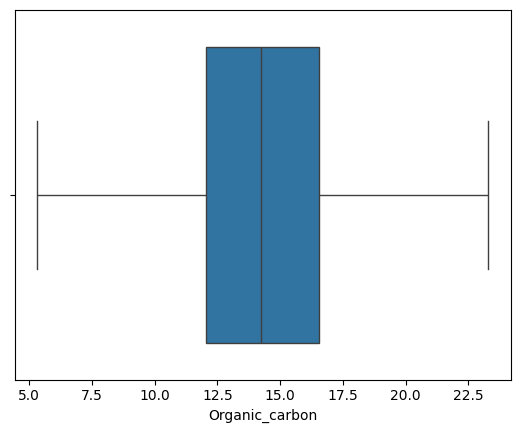

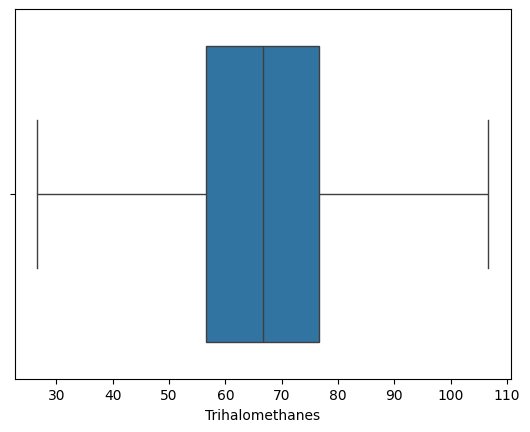

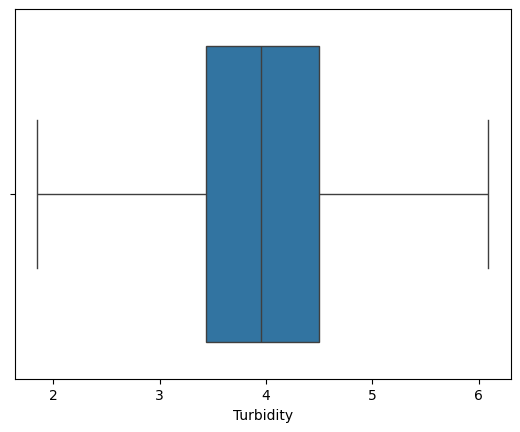

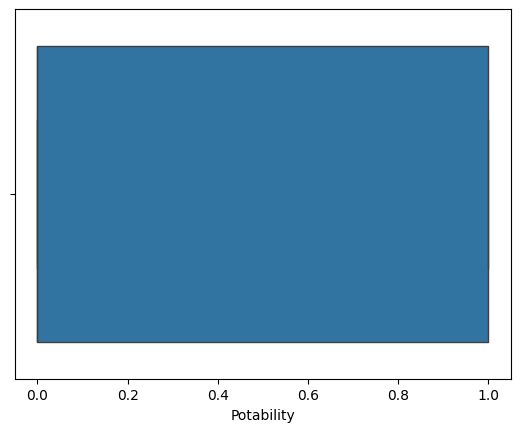

In [15]:
warnings.filterwarnings('ignore')
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()

In [16]:
X = df.drop(columns=['Potability'])
y = df['Potability']
X

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.889107,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,44831.869873,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821
3272,7.808856,193.553212,17329.802160,8.061362,333.073546,392.449580,19.903225,66.622485,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,333.073546,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,333.073546,402.883113,11.168946,77.488213,4.708658


In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
#logistic regression
model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)


In [20]:
score = accuracy_score(y_test,y_pred)
score

0.5396341463414634

In [21]:
rf = RandomForestClassifier()
rf.fit(X_train_scaled,y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [22]:
score1 = accuracy_score(y_test,y_pred_rf)
score1

0.6692073170731707

In [23]:
#precision score logistic regression
precision = precision_score(y_test,y_pred)
precision

0.4195583596214511

In [24]:
#precision score random forest
precision_rf = precision_score(y_test,y_pred_rf)
precision_rf

0.6133333333333333

In [25]:
#recall score logistic regression
recall = recall_score(y_test,y_pred)
recall

0.5298804780876494

In [26]:
#recall score random forest
recall_rf = recall_score(y_test,y_pred_rf)
recall_rf

0.3665338645418327

In [27]:
#f1 score logistic regression
f1 = f1_score(y_test,y_pred)
f1

0.46830985915492956

In [28]:
#f1 score for random forest
f1_rf = f1_score(y_test,y_pred_rf)
f1_rf

0.45885286783042395

In [32]:
with open('lr_model.pkl','wb') as f:
    pickle.dump(model,f)

In [31]:
with open('rf_model.pkl','wb') as f:
    pickle.dump(rf,f)